<a href="https://colab.research.google.com/github/hursoo/big_k-modern_1/blob/main/gb_081_topic_extract(big1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.개요 및 기본설정
- DMR 적용해서 "개벽" 논조변화 분석
- 입력 데이터: gb_031에서 생성한 '기본 데이터프레임' <- 소스: 'gb_data_2.1.xlsx'

In [1]:
# =================================================================
# 셀 1: 라이브러리 설치
# =================================================================
# 설치 과정 표시, 에러 출력은 숨김

!pip install -q tomotopy==0.13.0 numpy==1.23.5 kneed 2> /dev/null # 2> /dev/null : 에러 출력 메시지를 숨깁니다.

# =================================================================
# 셀 1-1: 나눔 폰트 설치
# =================================================================
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 12.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,339 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at

=> "런타임 / 세션 다시 시작"

In [1]:
# =================================================================
# 셀 2: 기본 설정 및 라이브러리 임포트
# =================================================================
# "세션 다시 시작" 후에 이 셀부터 실행합니다.

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')
print("\n✅ 구글 드라이브 마운트 완료!")

# 경로 지정
file_path = '/content/drive/MyDrive/big_km_history01/'

Mounted at /content/drive

✅ 구글 드라이브 마운트 완료!


In [2]:
import sys
import os, re
import pandas as pd
import numpy as np
print(np.__version__)
import random
import warnings

from tomotopy import DMRModel
from tomotopy import TermWeight
from tomotopy import utils
import tomotopy as tp

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumBarunGothic' # 나눔바른고딕으로 설정 (Colab 기본 포함) ###
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호가 정상 표시되도록 설정

1.23.5


In [3]:
# gb_031에서 생성한 '기본 데이터프레임' 불러오기

gb_df = pd.read_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls).xlsx')
gb_df

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0
3,4,사람과 世界는 決코 논하볼 것이 안이엇다 사람으로 된 世界 世界로 된 사람 둘이 안...,사람 세계 사람 세계 세계 사람 세계 대표 시대 가치 사람 대표 문화 상징 符號 사...,2,世界를 알라,uk01,1,01q,0
4,5,過去는 論할 것이 업도다만은 今日과 가티 交通이 이마마하고 知識이 이마마하고 一切의...,過去 금일 교통 지식 일체 문물 오늘 세계 理解 공자 천하 천하 理解 오늘 날 사람...,2,世界를 알라,uk01,1,01q,0
...,...,...,...,...,...,...,...,...,...
6797,6798,미국에서는 每人에게 奴僕이 식 돌아감니다 단 機械奴僕만 이건 무슨 말이냐 하면 기계...,미국 노복 機械 노복 機械 力 운전 계산 人力 계산 미국 국민 사람 機械 輸入 숫자...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2
6798,6799,매년 저축은ㅡ필요의 비용을 다 쓴 뒤의 것 말이지요ㅡ매년에 억 딸라 金 루불로는 억...,저축 필요 비용 미국 교과 書 실상 미국 富豪 캐나다 영국 미국 부분 미국 캐나다 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2
6799,6800,그러고 또 캐나다는 아조 겸손스럽게 좀 유순하게 미국의 北邊繼續이라고ㅡ국제연맹의 축...,캐나다 미국 국제_연맹 국제_연맹 원인 경제 機械 캐나다 산업 북미 자본 점령 부분...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2
6800,6801,25년 전에는 영국이 美보다 배나 더 되게 輸入하엿섯음니다 캐나다 사람들은 지금 그...,영국 미국 輸入 캐나다 사람 영국 一部 미국 호주 캐나다 진화 호주 일본 침입 보호...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2


# 2.1단계(토픽추출)
- 혼잡도 사용
- 변화율 분석
- 1차 토픽

##  2.1.Model perplexity 산출

Running LDA...
Model perplexity (Log-likelihood)
LDA 모델 학습 시작... (k=1 to 20)
k= 1 | Log-likelihood: -7.5475
k= 2 | Log-likelihood: -7.5988
k= 3 | Log-likelihood: -7.6035
k= 4 | Log-likelihood: -7.6155
k= 5 | Log-likelihood: -7.6226
k= 6 | Log-likelihood: -7.6274
k= 7 | Log-likelihood: -7.6192
k= 8 | Log-likelihood: -7.6409
k= 9 | Log-likelihood: -7.6183
k=10 | Log-likelihood: -7.6241
k=11 | Log-likelihood: -7.6265
k=12 | Log-likelihood: -7.6035
k=13 | Log-likelihood: -7.6043
k=14 | Log-likelihood: -7.6112
k=15 | Log-likelihood: -7.5888
k=16 | Log-likelihood: -7.5746
k=17 | Log-likelihood: -7.5891
k=18 | Log-likelihood: -7.5911
k=19 | Log-likelihood: -7.5765
k=20 | Log-likelihood: -7.5568


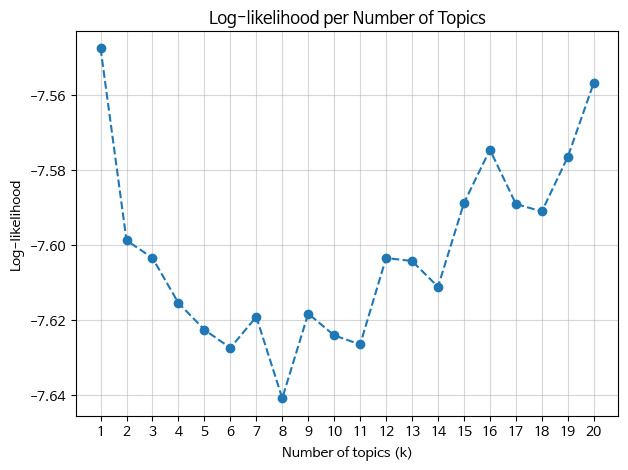

In [4]:
# RuntimeWarning 무시
warnings.filterwarnings("ignore", category=RuntimeWarning)

def calculate_log_likelihoods(corpus, train_steps=500, seed=100):
    """
    주어진 코퍼스를 사용하여 k=1부터 20까지 LDA 모델을 학습하고,
    각 k값에 대한 Log-likelihood를 계산합니다.

    Args:
        corpus (list): ['단어1', '단어2', ...] 형태의 문서 리스트
        train_steps (int): 모델 학습 반복 횟수
        seed (int): 결과 재현성을 위한 시드값

    Returns:
        list, list: 토픽 수(k) 리스트, Log-likelihood 값 리스트
    """
    ntopics = []
    log_likelihoods = []

    print("LDA 모델 학습 시작... (k=1 to 20)")
    # k값을 1부터 20까지 변경하며 반복
    for k in range(1, 21):
        mdl = tp.LDAModel(k=k, seed=seed)
        for line in corpus:
            doc = line.strip().split(' ')
            mdl.add_doc(doc)
        mdl.burn_in = 50
        mdl.train(train_steps, workers=1) # workers=1로 고정

        ntopics.append(k)
        log_likelihoods.append(mdl.ll_per_word)
        print(f"k={k:2d} | Log-likelihood: {mdl.ll_per_word:.4f}")

    return ntopics, log_likelihoods


def plot_log_likelihood(ntopics, log_likelihoods):
    """
    토픽 수에 따른 Log-likelihood 그래프를 그립니다.
    """
    plt.figure(figsize=(7, 5))
    plt.plot(ntopics, log_likelihoods, marker='o', linestyle='--')
    plt.xlabel("Number of topics (k)")
    plt.ylabel("Log-likelihood")
    plt.title("Log-likelihood per Number of Topics")
    plt.xticks(ntopics)
    plt.grid(True, alpha=0.5)
    plt.show()

# === 실행 ===
print("Running LDA...")
print("Model perplexity (Log-likelihood)")

# gb_df['doc_split_12gram'] 컬럼만 리스트화해서 모델 학습
windowL = gb_df['doc_split_12gram'].to_list()

# 함수 호출
ntopics, log_likelihoods = calculate_log_likelihoods(windowL)

# 그래프 그리기
plot_log_likelihood(ntopics, log_likelihoods)

## 2.2.Model Coherence 산출

LDA 모델 Coherence 점수 계산 시작... (k=1 to 20)
k= 1 | Coherence(c_v): 0.2002
k= 2 | Coherence(c_v): 0.4719
k= 3 | Coherence(c_v): 0.5211
k= 4 | Coherence(c_v): 0.5695
k= 5 | Coherence(c_v): 0.5741
k= 6 | Coherence(c_v): 0.6035
k= 7 | Coherence(c_v): 0.6210
k= 8 | Coherence(c_v): 0.6573
k= 9 | Coherence(c_v): 0.7280
k=10 | Coherence(c_v): 0.6686
k=11 | Coherence(c_v): 0.6207
k=12 | Coherence(c_v): 0.6899
k=13 | Coherence(c_v): 0.6688
k=14 | Coherence(c_v): 0.6813
k=15 | Coherence(c_v): 0.7164
k=16 | Coherence(c_v): 0.6999
k=17 | Coherence(c_v): 0.7000
k=18 | Coherence(c_v): 0.6464
k=19 | Coherence(c_v): 0.6909
k=20 | Coherence(c_v): 0.6857

Coherence 점수가 가장 높은 최적의 토픽 수(k): 9 (점수: 0.7280)


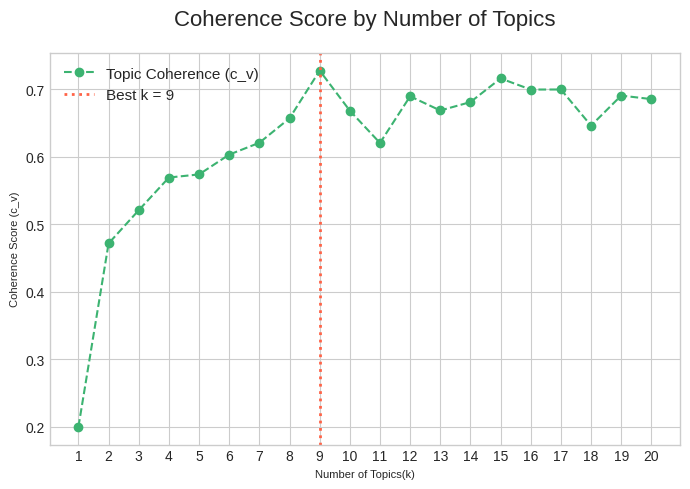

In [5]:

# 3. 데이터 준비 (예시 데이터)
corpus_list = gb_df['doc_split_12gram'].to_list()

# 4. Coherence 점수 계산 함수 정의
def calculate_coherence(corpus, k_start=2, k_end=20, train_steps=500, seed=100):
    """
    주어진 코퍼스를 사용하여 k_start부터 k_end까지 LDA 모델을 학습하고,
    각 k값에 대한 Coherence(c_v) 점수를 계산합니다.
    """
    ntopics = []
    coherence_scores = []

    print(f"LDA 모델 Coherence 점수 계산 시작... (k={k_start} to {k_end})")
    for k in range(k_start, k_end + 1):
        # Coherence 계산 시 PMI 가중치(tw=tp.TermWeight.PMI) 사용이 권장됩니다.
        mdl = tp.LDAModel(k=k, seed=seed, tw=tp.TermWeight.PMI)
        for line in corpus:
            doc = line.strip().split(' ')
            mdl.add_doc(doc)

        mdl.burn_in = 50
        mdl.train(train_steps, workers=1)

        # 'c_v' Coherence 계산
        coh = tp.coherence.Coherence(mdl, coherence='c_v')
        coherence_value = coh.get_score()

        ntopics.append(k)
        coherence_scores.append(coherence_value)
        print(f"k={k:2d} | Coherence(c_v): {coherence_value:.4f}")

    return ntopics, coherence_scores


# 5. 함수 실행 및 최적 k 찾기
ntopics_coh, coherence_scores = calculate_coherence(corpus_list, k_start=1, k_end=20)

if coherence_scores:
    best_k_index = np.argmax(coherence_scores)
    best_k = ntopics_coh[best_k_index]
    best_score = coherence_scores[best_k_index]
    print(f"\nCoherence 점수가 가장 높은 최적의 토픽 수(k): {best_k} (점수: {best_score:.4f})")
else:
    best_k = None
    print("\nCoherence 점수를 계산하지 못했습니다.")


# 6. 결과 시각화
if coherence_scores:
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(7, 5))

    plt.plot(ntopics_coh, coherence_scores, marker='o', linestyle='--', color='mediumseagreen', label='Topic Coherence (c_v)')

    if best_k is not None:
        plt.axvline(x=best_k, color='tomato', linestyle=':', linewidth=2, label=f'Best k = {best_k}')

    plt.xlabel("Number of Topics(k)", fontsize=8)
    plt.ylabel("Coherence Score (c_v)", fontsize=8)
    plt.title("Coherence Score by Number of Topics", fontsize=16, pad=20)
    plt.xticks(ntopics_coh)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

#3.토픽 산출 및 seed 검토

## 3.1.토픽 산출 함수

In [6]:
# 1) OpenMP 스레드 수 제한 (결과 재현성을 위해)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# 2) 파이썬 자체 random, numpy 랜덤 시드 고정
def set_global_seeds(seed_value=1000):
    random.seed(seed_value)
    np.random.seed(seed_value)

# 3) `a_data`를 `metadata`로 변환하는 함수
def transform_a_data_to_metadata(misc: dict):
    return {'metadata': str(misc['a_data'])}

def run_dmr_model(gridL, lineL, num_topics=10, seed=100, iterations=1000, alpha=0.1, eta=0.01):
    """
    DMR 모델 실행 및 메타데이터 저장.
    """
    # 파이썬 랜덤, numpy 랜덤 시드 고정
    set_global_seeds(seed)

    print(f"\nTraining DMR Model with {num_topics} topics, alpha={alpha}, eta={eta}...")

    # DMR 모델 초기화 (tomotopy 내부 시드 설정)
    model = DMRModel(
        k=num_topics,
        seed=seed,
        tw=TermWeight.ONE,
        alpha=alpha,
        eta=eta
    )
    corpus = utils.Corpus()

    # 코퍼스에 문서 추가 (lineL은 이미 단어 리스트로 전처리되었다고 가정)
    for grid, tokens in zip(gridL, lineL):
        corpus.add_doc(tokens, a_data=grid)

    # 모델에 코퍼스 추가 (메타데이터 변환 포함)
    model.add_corpus(corpus, transform=transform_a_data_to_metadata)

    # 학습
    for i in range(0, iterations, 20):  # 20단위로 학습 반복
        model.train(20, workers=1) ### 결과 고정 위해
        print(f"Iteration: {i + 20}\tLog-likelihood: {model.ll_per_word:.4f}")

    # --- ✨ 변경점: 토픽별 단어 수를 직접 계산 ---
    # DMRModel에는 count_by_topics 속성이 없으므로,
    # 모든 문서의 단어-토픽 할당을 기반으로 직접 계산합니다.
    topic_counts = [0] * model.k
    for doc in model.docs:
        for topic_idx in doc.topics:
            topic_counts[topic_idx] += 1

    print("\n<Topics>")
    # 각 토픽의 정보(단어 수, 상위 단어)를 가져와서 형식에 맞게 출력
    for i in range(model.k):
        # 직접 계산한 토픽별 단어 수 가져오기
        topic_word_count = topic_counts[i]

        # 토픽별 상위 단어 20개 가져오기
        top_words = model.get_topic_words(i, top_n=20)

        # 단어만 추출하여 공백으로 연결
        word_list = [word[0] for word in top_words]
        words_str = ' '.join(word_list)

        # 최종 형식으로 출력
        print(f"| #{i} ({topic_word_count}) : {words_str}")

    # 원래 코드와의 호환성을 위해 topics 리스트도 반환
    topics = [model.get_topic_words(i, top_n=20) for i in range(model.k)]

    return model, topics

## 3.2.seed 검토

In [7]:
# ============ seed 검토 (Colab/현재 run_dmr_model 전제) ============

import time
import numpy as np
from collections import Counter, defaultdict
from itertools import combinations
from scipy.optimize import linear_sum_assignment

# ------ 헬퍼 ------
def get_topics_from_model(model, top_n=20):
    topics_words = []
    topics_dists = []
    for i in range(model.k):
        wp = model.get_topic_words(i, top_n=top_n)
        # 확률 동률 시 단어 사전순으로 안정 정렬
        wp_sorted = sorted(wp, key=lambda x: (-x[1], x[0]))
        topics_words.append([w for w,_ in wp_sorted])
        topics_dists.append({w:p for w,p in wp_sorted})
    return topics_words, topics_dists

def build_doc_term_sets(lineL):
    return [set(tokens) for tokens in lineL]

def coherence_umass(topics_words, doc_sets, eps=1.0):
    # 문서별 DF
    df = Counter()
    for s in doc_sets:
        for w in s:
            df[w] += 1

    # 동출현 DF
    pair_df = defaultdict(int)
    for s in doc_sets:
        arr = sorted(list(s))
        for i in range(len(arr)):
            wi = arr[i]
            for j in range(i+1, len(arr)):
                wj = arr[j]
                pair_df[(wi, wj)] += 1

    def pair_count(a,b):
        x,y = sorted([a,b])
        return pair_df.get((x,y), 0)

    topic_scores = []
    for words in topics_words:
        vals = []
        for i in range(1, len(words)):
            for j in range(0, i):
                wi, wj = words[i], words[j]
                cij = pair_count(wi, wj)
                dj  = df.get(wj, 0)
                vals.append(np.log((cij + eps) / (dj + eps)))
        topic_scores.append(np.mean(vals) if vals else 0.0)
    return float(np.mean(topic_scores)) if topic_scores else 0.0

def intertopic_jaccard_overlap(topics_words):
    sets = [set(ws) for ws in topics_words]
    vals = []
    for a,b in combinations(range(len(sets)), 2):
        inter = len(sets[a] & sets[b])
        union = len(sets[a] | sets[b]) or 1
        vals.append(inter/union)
    return float(np.mean(vals)) if vals else 0.0

def topic_word_diversity(topics_words):
    all_words = [w for ws in topics_words for w in ws]
    return len(set(all_words)) / (len(all_words) or 1)

def zscore_list(vals):
    arr = np.array(vals, dtype=float)
    m = arr.mean()
    s = arr.std()
    if s == 0:
        return np.zeros_like(arr)
    return (arr - m) / s

def jaccard_set(a, b):
    sa, sb = set(a), set(b)
    inter = len(sa & sb)
    union = len(sa | sb) or 1
    return inter / union

def stability_all_seeds(seed_topics_words_dict):
    """
    모든 seed 쌍에 대해 토픽 매칭(헝가리안) 후 평균 Jaccard 유사도.
    반환: {seed: 평균 안정성}
    """
    seeds = list(seed_topics_words_dict.keys())
    S = {}
    for s in seeds:
        base = seed_topics_words_dict[s]
        vs = []
        for t in seeds:
            if t == s:
                continue
            other = seed_topics_words_dict[t]
            k = min(len(base), len(other))
            cost = np.zeros((k,k))
            for i in range(k):
                for j in range(k):
                    cost[i,j] = 1.0 - jaccard_set(base[i], other[j])
            row_ind, col_ind = linear_sum_assignment(cost)
            sim = 1.0 - cost[row_ind, col_ind].mean()
            vs.append(sim)
        S[s] = float(np.mean(vs)) if vs else 0.0
    return S

# ------ 평가 파이프라인 ------
def evaluate_seeds_weighted(
    gridL, lineL, seeds,
    num_topics=8, iterations=500, alpha=0.05, eta=0.1,
    top_n=20,
    # 가중치(요청안): Coh 2, Sep 1.5(= -1.5 * z(jaccard)), Div 1, Stab 1
    w_coh=2.0, w_sep=1.5, w_div=1.0, w_stab=1.0
):
    t0 = time.time()

    # A) seed별 학습 + 1차 지표 산출
    doc_sets = build_doc_term_sets(lineL)
    rows = []
    topics_by_seed = {}

    print(f"\n[ RUN ] evaluating seeds ... (iterations={iterations})")
    for sd in seeds:
        s1 = time.time()
        model, _ = run_dmr_model(
            gridL, lineL,
            num_topics=num_topics, seed=sd, iterations=iterations,
            alpha=alpha, eta=eta
        )
        topics_words, _ = get_topics_from_model(model, top_n=top_n)

        coh = coherence_umass(topics_words, doc_sets)              # ↑ good
        jac = intertopic_jaccard_overlap(topics_words)             # ↓ good
        div = topic_word_diversity(topics_words)                   # ↑ good

        topics_by_seed[sd] = topics_words
        s2 = time.time()

        rows.append({
            "seed": sd,
            "coherence_umass": float(coh),
            "inter_jaccard": float(jac),
            "diversity": float(div),
            "elapsed_sec_seed": round(s2 - s1, 3)
        })
        print(f" - seed {sd:>3}: coh={coh:.4f}, interJ={jac:.4f}, div={div:.4f}  (elapsed {s2-s1:.2f}s)")

    # B) 안정성(모든 seed 대상)
    print("\n[ RUN ] computing stability across seeds ...")
    stab_map = stability_all_seeds(topics_by_seed)  # ↑ good
    for r in rows:
        r["stability"] = float(stab_map.get(r["seed"], 0.0))

    # C) 지표 표준화(z) + 가중합 총점
    coh_z = zscore_list([r["coherence_umass"] for r in rows])
    jac_z = zscore_list([r["inter_jaccard"]    for r in rows])
    div_z = zscore_list([r["diversity"]        for r in rows])
    stab_z= zscore_list([r["stability"]        for r in rows])

    for i, r in enumerate(rows):
        # Separation은 inter_jaccard ↓가 좋으므로 -w_sep * z(jac)
        final = (w_coh * coh_z[i]) + (-w_sep * jac_z[i]) + (w_div * div_z[i]) + (w_stab * stab_z[i])
        r["z_coh"]  = float(coh_z[i])
        r["z_sep"]  = float(-jac_z[i])  # 해석 편의상: "분리도 z"는 부호 뒤집어 저장(+가 좋음)
        r["z_div"]  = float(div_z[i])
        r["z_stab"] = float(stab_z[i])
        r["final_score"] = float(final)

    # D) 상위 5개 요약 출력 (총점 내림차순)
    rows_sorted = sorted(rows, key=lambda x: x["final_score"], reverse=True)
    top5 = rows_sorted[:5]

    print("\n================== [ TOP 5 by FINAL SCORE ] ==================")
    print("(rank) seed | final_score |  coh(z,w=2)  sep(z,w=1.5)  div(z,w=1)  stab(z,w=1)")
    for rank, r in enumerate(top5, start=1):
        comp = (
            f"{rank:>2})  {r['seed']:>3}  | "
            f"{r['final_score']:+.4f}  |  "
            f"{r['z_coh']:+.3f}×2  "
            f"{r['z_sep']:+.3f}×1.5  "
            f"{r['z_div']:+.3f}×1  "
            f"{r['z_stab']:+.3f}×1"
        )
        print(comp)

    t1 = time.time()
    total_elapsed = round(t1 - t0, 2)
    print(f"\n[ DONE ] total elapsed: {total_elapsed} sec")

    return rows_sorted, top5, total_elapsed


# =============== 함수 실행 (iter=500) ====================

gridL = gb_df['grid_1'].tolist()
lineL = gb_df['doc_split_12gram'].apply(lambda x: str(x).split()).tolist()

seeds = list(range(1, 21))  # 20개
rows_sorted, top5, total_elapsed = evaluate_seeds_weighted(
    gridL, lineL, seeds=seeds,
    num_topics=8, iterations=500, alpha=0.05, eta=0.1,
    top_n=20,
    w_coh=2.0, w_sep=1.5, w_div=1.0, w_stab=1.0
)


[ RUN ] evaluating seeds ... (iterations=500)

Training DMR Model with 8 topics, alpha=0.05, eta=0.1...
Iteration: 20	Log-likelihood: -7.8739
Iteration: 40	Log-likelihood: -7.7080
Iteration: 60	Log-likelihood: -7.6668
Iteration: 80	Log-likelihood: -7.6493
Iteration: 100	Log-likelihood: -7.6380
Iteration: 120	Log-likelihood: -7.6231
Iteration: 140	Log-likelihood: -7.6229
Iteration: 160	Log-likelihood: -7.6189
Iteration: 180	Log-likelihood: -7.6179
Iteration: 200	Log-likelihood: -7.6188
Iteration: 220	Log-likelihood: -7.6153
Iteration: 240	Log-likelihood: -7.6184
Iteration: 260	Log-likelihood: -7.6164
Iteration: 280	Log-likelihood: -7.6167
Iteration: 300	Log-likelihood: -7.6163
Iteration: 320	Log-likelihood: -7.6164
Iteration: 340	Log-likelihood: -7.6140
Iteration: 360	Log-likelihood: -7.6164
Iteration: 380	Log-likelihood: -7.6155
Iteration: 400	Log-likelihood: -7.6202
Iteration: 420	Log-likelihood: -7.6145
Iteration: 440	Log-likelihood: -7.6130
Iteration: 460	Log-likelihood: -7.6133
It

# 4.3단계(토픽 확정)
- 주요 seed 검토
- 3차 토픽
- 토픽 명명

## 4.1.seed Top 5 검토

In [8]:
# run_dmr_model() 등 토픽 산출 함수를 전제

# 함수 실행 (후보 seed 5개, iter=1000)

gridL = gb_df['grid_1'].tolist()
lineL = gb_df['doc_split_12gram'].apply(lambda x: str(x).split()).tolist()

seeds = [2,8,20,15,7]  # 상위 5개
rows_sorted, top5, total_elapsed = evaluate_seeds_weighted(
    gridL, lineL, seeds=seeds,
    num_topics=8, iterations=1000, alpha=0.05, eta=0.1,
    top_n=20,
    w_coh=2.0, w_sep=1.5, w_div=1.0, w_stab=1.0
)


[ RUN ] evaluating seeds ... (iterations=1000)

Training DMR Model with 8 topics, alpha=0.05, eta=0.1...
Iteration: 20	Log-likelihood: -7.9073
Iteration: 40	Log-likelihood: -7.7173
Iteration: 60	Log-likelihood: -7.6725
Iteration: 80	Log-likelihood: -7.6509
Iteration: 100	Log-likelihood: -7.6375
Iteration: 120	Log-likelihood: -7.6273
Iteration: 140	Log-likelihood: -7.6199
Iteration: 160	Log-likelihood: -7.6145
Iteration: 180	Log-likelihood: -7.6120
Iteration: 200	Log-likelihood: -7.6112
Iteration: 220	Log-likelihood: -7.6123
Iteration: 240	Log-likelihood: -7.6071
Iteration: 260	Log-likelihood: -7.6045
Iteration: 280	Log-likelihood: -7.6040
Iteration: 300	Log-likelihood: -7.5996
Iteration: 320	Log-likelihood: -7.6033
Iteration: 340	Log-likelihood: -7.6011
Iteration: 360	Log-likelihood: -7.6035
Iteration: 380	Log-likelihood: -7.6036
Iteration: 400	Log-likelihood: -7.5997
Iteration: 420	Log-likelihood: -7.5986
Iteration: 440	Log-likelihood: -7.6022
Iteration: 460	Log-likelihood: -7.6006
I

## 4.2.최종 seed 출력
- seed=7

In [18]:
# 최종 seed 실행 (iter=1000) ====================

## (Colab/현재 run_dmr_model 전제)

gridL = gb_df['grid_1'].tolist()
lineL = gb_df['doc_split_12gram'].apply(lambda x: str(x).split()).tolist()

model, topics = run_dmr_model(
    gridL, lineL,
    num_topics=8, seed=7, iterations=1000, alpha=0.05, eta=0.1)


Training DMR Model with 8 topics, alpha=0.05, eta=0.1...
Iteration: 20	Log-likelihood: -7.8370
Iteration: 40	Log-likelihood: -7.7045
Iteration: 60	Log-likelihood: -7.6746
Iteration: 80	Log-likelihood: -7.6570
Iteration: 100	Log-likelihood: -7.6406
Iteration: 120	Log-likelihood: -7.6298
Iteration: 140	Log-likelihood: -7.6241
Iteration: 160	Log-likelihood: -7.6265
Iteration: 180	Log-likelihood: -7.6206
Iteration: 200	Log-likelihood: -7.6148
Iteration: 220	Log-likelihood: -7.6125
Iteration: 240	Log-likelihood: -7.6115
Iteration: 260	Log-likelihood: -7.6079
Iteration: 280	Log-likelihood: -7.6026
Iteration: 300	Log-likelihood: -7.6080
Iteration: 320	Log-likelihood: -7.6051
Iteration: 340	Log-likelihood: -7.6025
Iteration: 360	Log-likelihood: -7.6056
Iteration: 380	Log-likelihood: -7.6066
Iteration: 400	Log-likelihood: -7.6027
Iteration: 420	Log-likelihood: -7.6039
Iteration: 440	Log-likelihood: -7.6023
Iteration: 460	Log-likelihood: -7.6023
Iteration: 480	Log-likelihood: -7.6020
Iteration:

In [16]:
model.summary()

<Basic Info>
| DMRModel (current version: 0.13.0)
| 6802 docs, 257159 words
| Total Vocabs: 5828, Used Vocabs: 5828
| Entropy of words: 7.43552
| Entropy of term-weighted words: 7.43552
| Removed Vocabs: <NA>
| Metadata of docs and its distribution
|  01q: 193
|  02q: 223
|  03q: 296
|  04q: 292
|  05q: 435
|  06q: 333
|  07q: 410
|  08q: 413
|  09q: 152
|  10q: 298
|  11q: 315
|  12q: 261
|  13q: 198
|  14q: 393
|  15q: 456
|  16q: 254
|  17q: 154
|  18q: 201
|  19q: 223
|  20q: 224
|  21q: 226
|  22q: 248
|  23q: 324
|  24q: 280
|
<Training Info>
| Iterations: 1000, Burn-in steps: 0
| Optimization Interval: 10
| Log-likelihood per word: -7.60149
|
<Initial Parameters>
| tw: TermWeight.ONE
| min_cf: 0 (minimum collection frequency of words)
| min_df: 0 (minimum document frequency of words)
| rm_top: 0 (the number of top words to be removed)
| k: 8 (the number of topics between 1 ~ 32767)
| alpha: [0.05] (an initial value of exponential of mean of normal distribution for `lambdas`, giv

In [17]:
# 모델 저장
model.save(file_path + 'result/gb_n_dmr_model(k=8,seed=7,0.05,0.1).bin') ###

## 4.3.토픽 명명

In [53]:
# 토픽 단어를 통해 토픽 이름을 추출 (연구자)

label_text = '''T0: 근대·민족·문명 담론 (사상/민족/문명/개조/세계/역사)
T1: 전통사상 비판/재독해 (유교/노장/주자/묵자/철학/당쟁)
T2: 농업·토지·노동 문제 (토지/소작/지주/농민/생산/노동)
T3: 사회주의·혁명·계급 (사회주의/자본주의/혁명/조직/부르주아)
T4: 개인·자유·도덕·평등 (자유/개인/인격/평등/행복)
T5: 인간·의식·종교·우주관 (의식/종교/진리/우주/과학/예술)
T6: 교육·청년·기관·지식 (학교/청년/단체/기관/신문/지식)
T7: 국제정치·전쟁·열강 (국제/전쟁/영국/미국/일본/정책)
'''

In [54]:
# 토픽 라벨을 딕셔너리 형태로 추출

topic_labels={}
for n, line in enumerate(label_text.split('\n')):
    lines = line.strip().split(' (')[0]
    liness = lines.split(': ')[-1]
    topic_labels[n] = liness
topic_labels

{0: '근대·민족·문명 담론',
 1: '전통사상 비판/재독해',
 2: '농업·토지·노동 문제',
 3: '사회주의·혁명·계급',
 4: '개인·자유·도덕·평등',
 5: '인간·의식·종교·우주관',
 6: '교육·청년·기관·지식',
 7: '국제정치·전쟁·열강',
 8: ''}

In [55]:
# 전제 : model, topics, 토픽 라벨 등이 이미 도출되어 있음.

# 결과를 DataFrame으로 정리 (예: 토픽 인덱스, 라벨, 상위 단어)
topic_data = []
for idx, topic in enumerate(topics):
    label = topic_labels.get(idx, f"Topic_{idx}")  # 혹시 라벨 딕셔너리에 없으면 'Topic_인덱스'로 fallback
    # 토픽의 상위 단어를 추출 (단어만)
    top_words = [word[0] for word in topic]
    # 하나의 문자열로 합치거나, 리스트 그대로 저장 가능
    top_words_str = ", ".join(top_words)

    # row 구성
    row = {
        "Topic_Index": idx,
        "Topic_Label": label,
        "Top_Words": top_words_str
    }
    topic_data.append(row)

In [58]:
df_topics = pd.DataFrame(topic_data, columns=["Topic_Index", "Topic_Label", "Top_Words"])
df_topics

# Excel로 저장 (원하면)
df_topics.to_excel(file_path + "result/dmr_topics(토픽명 부착).xlsx", index=False)

,Topic_Index,Topic_Label,Top_Words
0,0,근대·민족·문명 담론,"사상, 민족, 문화, 新, 시대, 朝鮮, 세계, 민중, 문학, 중국, 문명, 정신,..."
1,1,전통사상 비판/재독해,"공자, 老子, 유교, 태조, 당쟁, 이조, 사상, 묵자, 朱子, 당시, 천하, 論,..."
2,2,농업·토지·노동 문제,"朝鮮, 경제, 朝鮮_人, 생활, 토지, 문제, 일본, 생산, 농민, 농업, 소작_人..."
3,3,사회주의·혁명·계급,"사회, 운동, 계급, 사회_主義, 主義, 자본_主義, 정치, 者, 사상, 혁명, 主..."
4,4,개인·자유·도덕·평등,"사회, 自己, 도덕, 개인, 主義, 인격, 자유, 생활, 인류, 국가, 사람, 평등..."
5,5,인간·의식·종교·우주관,"사람, 생활, 자연, 인간, 인류, 意識, 생명, 정신, 종교, 우주, 감정, 인생..."
6,6,교육·청년·기관·지식,"사람, 교육, 朝鮮, 단체, 학교, 사업, 청년, 형제, 사회, 문제, 힘, 소년,..."
7,7,국제정치·전쟁·열강,"세계, 영국, 일본, 미국, 프랑스, 국제, 중국, 전쟁, 국가, 독일, 主義, 러..."


# The End of Note